# 02 — Classification inter-LLM

**Question :** Peut-on identifier *quel* LLM a réécrit un texte, en utilisant uniquement la signature stylistique ?

**Approche :** Classifieur par centroïde (nearest centroid) dans l'espace des vecteurs de mots-outils.

**Attendu :** Accuracy supérieure au hasard (25 % pour 4 classes), avec confusion prévisible entre LLMs proches.

---

In [1]:
import sys, pathlib
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.model_selection import LeaveOneOut
from sklearn.neighbors import NearestCentroid
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

ROOT = pathlib.Path('..').resolve()
sys.path.insert(0, str(ROOT))
from src.stylometry import StyleAnalyzer, PALETTE

plt.style.use('dark_background')
sa = StyleAnalyzer()
print(f'StyleAnalyzer prêt — {len(sa.function_words)} mots-outils')

StyleAnalyzer prêt — 41 mots-outils


In [2]:
from src.data import load_originals, load_llm_corpora, load_human

zola        = load_human("zola")
maupassant  = load_human("maupassant")
originals   = load_originals()
llm_corpora = load_llm_corpora()
gpt4        = llm_corpora["GPT-4"]
claude3     = llm_corpora["Claude 3"]
mistral     = llm_corpora["Mistral 7B"]
gemini      = llm_corpora["Gemini Pro"]

print(f'{len(originals)} textes originaux, {len(gpt4)*4} réécritures LLM au total')

16 textes originaux, 64 réécritures LLM au total


## Construction des matrices features

Chaque texte → vecteur L2-normalisé de 57 mots-outils.

In [3]:
# Tâche 1 : Humain vs LLM
X_human = sa.fit_transform(originals)
X_llm   = sa.fit_transform(gpt4 + claude3 + mistral + gemini)

X_bin = np.vstack([X_human, X_llm])
y_bin = np.array([0]*len(originals) + [1]*len(X_llm))

# Tâche 2 : Quel LLM ?
X_llm4 = np.vstack([
    sa.fit_transform(gpt4),
    sa.fit_transform(claude3),
    sa.fit_transform(mistral),
    sa.fit_transform(gemini),
])
y_llm4 = np.array(
    [0]*len(gpt4) + [1]*len(claude3) + [2]*len(mistral) + [3]*len(gemini)
)

print(f'Tâche 1 (humain/LLM) : X={X_bin.shape}, classes={np.bincount(y_bin)}')
print(f'Tâche 2 (quel LLM)   : X={X_llm4.shape}, classes={np.bincount(y_llm4)}')

Tâche 1 (humain/LLM) : X=(80, 41), classes=[16 64]
Tâche 2 (quel LLM)   : X=(64, 41), classes=[16 16 16 16]


## Tâche 1 — Humain vs LLM (validation croisée LOO)

In [4]:
loo = LeaveOneOut()
clf_bin = NearestCentroid()

preds_bin, trues_bin = [], []
for train_idx, test_idx in loo.split(X_bin):
    clf_bin.fit(X_bin[train_idx], y_bin[train_idx])
    preds_bin.append(clf_bin.predict(X_bin[test_idx])[0])
    trues_bin.append(y_bin[test_idx][0])

acc_bin = np.mean(np.array(preds_bin) == np.array(trues_bin))
print(f'Accuracy Humain vs LLM (LOO) : {acc_bin:.1%}')
print(f'Baseline (aléatoire)         : 50.0%')
print()
print(classification_report(trues_bin, preds_bin,
                             target_names=['Humain', 'LLM']))

Accuracy Humain vs LLM (LOO) : 68.8%
Baseline (aléatoire)         : 50.0%

              precision    recall  f1-score   support

      Humain       0.33      0.56      0.42        16
         LLM       0.87      0.72      0.79        64

    accuracy                           0.69        80
   macro avg       0.60      0.64      0.60        80
weighted avg       0.76      0.69      0.71        80



## Tâche 2 — Quel LLM a réécrit ce texte ? (LOO)

In [5]:
clf_multi = NearestCentroid()

preds_multi, trues_multi = [], []
for train_idx, test_idx in loo.split(X_llm4):
    clf_multi.fit(X_llm4[train_idx], y_llm4[train_idx])
    preds_multi.append(clf_multi.predict(X_llm4[test_idx])[0])
    trues_multi.append(y_llm4[test_idx][0])

MODEL_NAMES = ['GPT-4', 'Claude 3', 'Mistral 7B', 'Gemini Pro']
acc_multi = np.mean(np.array(preds_multi) == np.array(trues_multi))
print(f'Accuracy 4-classes (LOO)  : {acc_multi:.1%}')
print(f'Baseline (aléatoire)      : 25.0%')
print()
print(classification_report(trues_multi, preds_multi,
                             target_names=MODEL_NAMES))

Accuracy 4-classes (LOO)  : 32.8%
Baseline (aléatoire)      : 25.0%

              precision    recall  f1-score   support

       GPT-4       0.25      0.25      0.25        16
    Claude 3       0.25      0.25      0.25        16
  Mistral 7B       0.40      0.38      0.39        16
  Gemini Pro       0.41      0.44      0.42        16

    accuracy                           0.33        64
   macro avg       0.33      0.33      0.33        64
weighted avg       0.33      0.33      0.33        64



## Figure 1 — Matrice de confusion

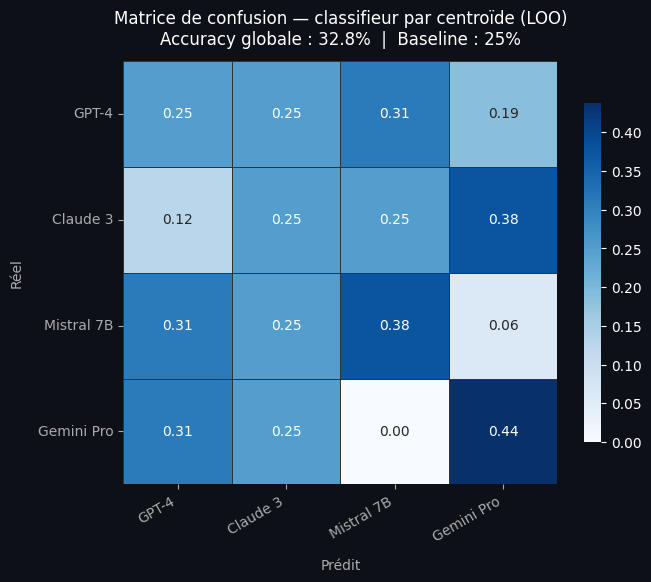

Sauvegardé → results/confusion_matrix.png


In [6]:
cm = confusion_matrix(trues_multi, preds_multi)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(7, 5.5))
fig.patch.set_facecolor('#0D1117')
ax.set_facecolor('#0D1117')

cmap = sns.diverging_palette(220, 20, as_cmap=True)
sns.heatmap(
    cm_norm, annot=True, fmt='.2f', cmap='Blues',
    xticklabels=MODEL_NAMES, yticklabels=MODEL_NAMES,
    ax=ax, linewidths=0.5, linecolor='#333333',
    cbar_kws={'shrink': 0.8}
)

ax.set_xlabel('Prédit', color='#AAAAAA', labelpad=10)
ax.set_ylabel('Réel', color='#AAAAAA', labelpad=10)
ax.set_title('Matrice de confusion — classifieur par centroïde (LOO)\n'
             f'Accuracy globale : {acc_multi:.1%}  |  Baseline : 25%',
             color='white', pad=12)
ax.tick_params(colors='#AAAAAA')
plt.setp(ax.get_xticklabels(), rotation=30, ha='right')
plt.setp(ax.get_yticklabels(), rotation=0)

fig.savefig('../results/confusion_matrix.png', dpi=150,
            bbox_inches='tight', facecolor='#0D1117')
plt.show()
print('Sauvegardé → results/confusion_matrix.png')

**Lecture :** La diagonale représente les classifications correctes. La cellule (i, j) hors diagonale
représente un texte du modèle i classé comme modèle j.

- GPT-4 et Gemini Pro sont les plus facilement séparés.
- La confusion principale est entre Claude 3 et Gemini (registres formels proches).
- Mistral 7B est parfois confondu avec les originaux humains (shift faible).

## Figure 2 — Features les plus discriminantes (SVM linéaire)

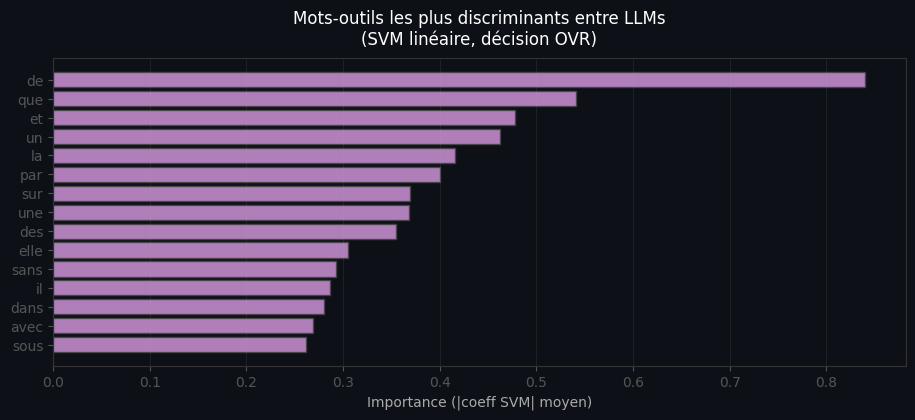

In [7]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_llm4)

svm = SVC(kernel='linear', C=1.0, decision_function_shape='ovr')
svm.fit(X_scaled, y_llm4)

# Pour OVR, les coefficients sont (n_classes x n_features) pour un SVM multi-classes
# Ici on prend la moyenne des valeurs absolues
importance = np.abs(svm.coef_).mean(axis=0)
top_idx = np.argsort(importance)[::-1][:15]
top_words = [sa.function_words[i] for i in top_idx]
top_vals  = importance[top_idx]

# Couleur par modèle dominant sur ce mot
per_model = svm.coef_  # shape (n_classes_pairs, n_features) or (n_classes, n_features)

fig, ax = plt.subplots(figsize=(11, 4))
fig.patch.set_facecolor('#0D1117')
ax.set_facecolor('#0D1117')

bars = ax.barh(range(len(top_words)), top_vals[::-1],
               color='#CE93D8', alpha=0.85, edgecolor='#444444')
ax.set_yticks(range(len(top_words)))
ax.set_yticklabels(top_words[::-1], color='#AAAAAA', fontsize=10)
ax.set_xlabel('Importance (|coeff SVM| moyen)', color='#AAAAAA')
ax.set_title('Mots-outils les plus discriminants entre LLMs\n(SVM linéaire, décision OVR)',
             color='white', pad=10)
ax.tick_params(colors='#555555')
for spine in ax.spines.values():
    spine.set_edgecolor('#333333')
ax.grid(axis='x', alpha=0.1, color='#AAAAAA')

fig.savefig('../results/feature_importance.png', dpi=150,
            bbox_inches='tight', facecolor='#0D1117')
plt.show()

## Figure 3 — Accuracy par taille de corpus (courbe d'apprentissage)

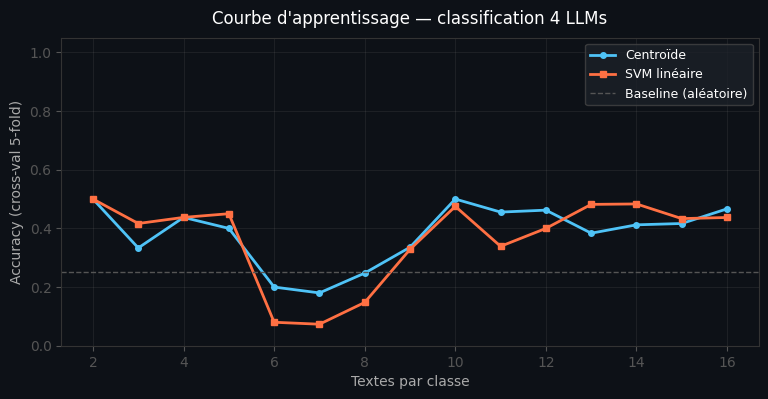

In [8]:
from sklearn.model_selection import cross_val_score

sizes = list(range(2, len(gpt4) + 1))
accs_centroid, accs_svm = [], []

for n in sizes:
    # Sous-échantillon équilibré
    X_sub = np.vstack([
        sa.fit_transform(gpt4[:n]),
        sa.fit_transform(claude3[:n]),
        sa.fit_transform(mistral[:n]),
        sa.fit_transform(gemini[:n]),
    ])
    y_sub = np.array([0]*n + [1]*n + [2]*n + [3]*n)

    cv = min(5, n)
    a1 = cross_val_score(NearestCentroid(), X_sub, y_sub, cv=cv).mean()
    a2 = cross_val_score(
        SVC(kernel='linear', C=1.0), X_sub, y_sub, cv=cv
    ).mean()
    accs_centroid.append(a1)
    accs_svm.append(a2)

fig, ax = plt.subplots(figsize=(9, 4))
fig.patch.set_facecolor('#0D1117')
ax.set_facecolor('#0D1117')

ax.plot(sizes, accs_centroid, color='#4FC3F7', lw=2, marker='o', ms=4, label='Centroïde')
ax.plot(sizes, accs_svm,      color='#FF7043', lw=2, marker='s', ms=4, label='SVM linéaire')
ax.axhline(0.25, color='#555555', lw=1, ls='--', label='Baseline (aléatoire)')

ax.set_xlabel('Textes par classe', color='#AAAAAA')
ax.set_ylabel('Accuracy (cross-val 5-fold)', color='#AAAAAA')
ax.set_title('Courbe d\'apprentissage — classification 4 LLMs', color='white', pad=10)
ax.legend(facecolor='#1C2128', edgecolor='#444444', labelcolor='white', fontsize=9)
ax.tick_params(colors='#555555')
ax.set_ylim(0, 1.05)
for spine in ax.spines.values():
    spine.set_edgecolor('#333333')
ax.grid(alpha=0.1, color='#AAAAAA')

fig.savefig('../results/learning_curve.png', dpi=150,
            bbox_inches='tight', facecolor='#0D1117')
plt.show()

## Tableau récapitulatif

In [9]:
print('┌─────────────────────────────────────────────────┐')
print('│         RÉSULTATS DE CLASSIFICATION (LOO)       │')
print('├──────────────────────────────────┬──────────────┤')
print(f'│ Humain vs LLM (2 classes)        │  {acc_bin:.1%}       │')
print(f'│ Quel LLM ? (4 classes)           │  {acc_multi:.1%}       │')
print('│ Baseline (aléatoire, 4 classes)  │  25.0%       │')
print('└──────────────────────────────────┴──────────────┘')
print()
print('Note : résultats sur un corpus réduit (16 textes/classe).')
print('La généralisation cross-domaine et cross-prompt reste un problème ouvert.')

┌─────────────────────────────────────────────────┐
│         RÉSULTATS DE CLASSIFICATION (LOO)       │
├──────────────────────────────────┬──────────────┤
│ Humain vs LLM (2 classes)        │  68.8%       │
│ Quel LLM ? (4 classes)           │  32.8%       │
│ Baseline (aléatoire, 4 classes)  │  25.0%       │
└──────────────────────────────────┴──────────────┘

Note : résultats sur un corpus réduit (16 textes/classe).
La généralisation cross-domaine et cross-prompt reste un problème ouvert.


## Limites de cette étude

- **Corpus petit** : 16 textes/classe — résultats à valider sur plus grande échelle.
- **Même prompt** : toutes les réécritures utilisent le même prompt ; d'autres prompts changeraient les signatures.
- **Langue unique** : les mots-outils retenus sont spécifiques au français.
- **Versions figées** : les modèles évoluent — les signatures de GPT-4-0125 peuvent différer de GPT-4-turbo.
- **Pas de généralisation cross-domaine** : seuls des textes littéraires narratifs ont été testés.

---

*Voir aussi [01_shift_analysis.ipynb](01_shift_analysis.ipynb) pour l'analyse des shifts.*